# Mudelprognoosi andmete mõistmiseks

Copernicus Atmosphere Monitoring Service (ECMWF) lehelt, Euroopa kaardil ühe suvalise parameetri näitel, kuidas mudeli väljund välja näeb(0.1 x 0.1 kraadi lagutus ehk u 11 x 11 km gridis andmed)

In [ ]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

url = "https://charts-dev.ecmwf.int/opencharts-api/v1/products/europe-particulate_matter_10um-forecast/"
params = {
    "base_time": "2026-05-29T00:00:00Z",
    "valid_time": "2026-05-29T00:00:00Z",
    "projection": "cams_aq_ne_europe"
}

r = requests.get(url, params=params, timeout=60)
print(r.status_code, r.headers.get("content-type"))

if "image" in str(r.headers.get("content-type", "")):
    img = Image.open(BytesIO(r.content))
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print(r.text[:2000])

200 application/json
{"data":{"type":"graphical_product","attributes":{"name":"europe-air-quality-forecast-regulated","title":"European air quality hourly forecast of regulated air pollutants","description":"Base time: Fri 29 May 2026 00 UTC Valid time: Fri 29 May 2026 00 UTC (+0h) Parameter : Nitrogen dioxide Area : North East Europe Model : Ensemble median Height level : Surface"},"link":{"href":"https://charts.ecmwf.int/content/20260529104320-99b2f78b743efdbb559de33dfe8d87649fea2619.png","type":"image/png"}},"meta":"Copernicus","template":"cams","tracker":"tracker-46e9175e69a64959befe09da184bf2bb","uid":""}


European air quality hourly forecast of regulated air pollutants
Base time: Fri 29 May 2026 00 UTC Valid time: Fri 29 May 2026 00 UTC (+0h) Parameter : Nitrogen dioxide Area : North East Europe Model : Ensemble median Height level : Surface
https://charts.ecmwf.int/content/20260529104320-99b2f78b743efdbb559de33dfe8d87649fea2619.png


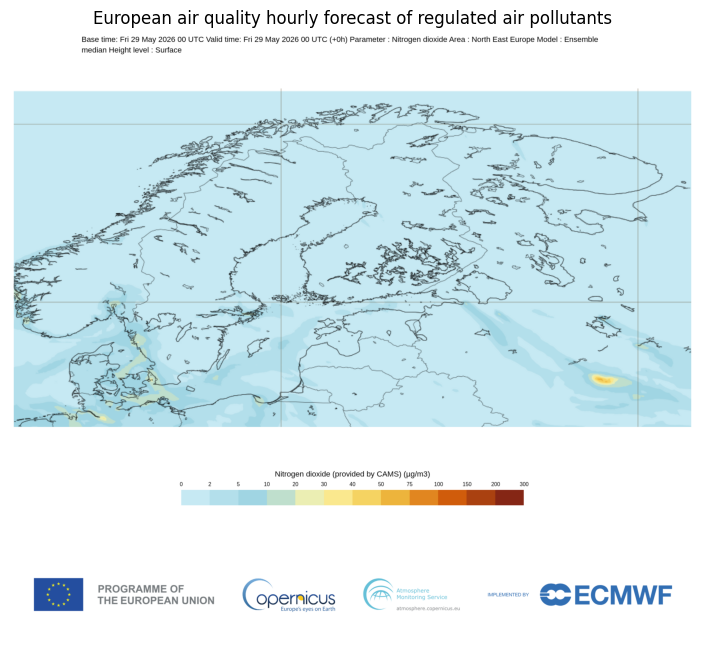

In [10]:
import requests
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO

api_url = "https://charts.ecmwf.int/opencharts-api/v1/products/europe-air-quality-forecast-regulated/?base_time=2026-05-29T00%3A00%3A00Z&valid_time=2026-05-29T00%3A00%3A00Z&layer_name=composition_europe_no2_forecast_surface"
params = {
    "base_time": "2026-05-29T00:00:00Z",
    "valid_time": "2026-05-29T00:00:00Z",
    "projection": "cams_aq_ne_europe"
}


r = requests.get(api_url, params=params, headers={"accept": "application/json"}, timeout=60)
r.raise_for_status()
meta = r.json()


img_url = meta["data"]["link"]["href"]
title = meta["data"]["attributes"]["title"]
description = meta["data"]["attributes"]["description"]

print(title)
print(description)
print(img_url)

img_resp = requests.get(img_url, timeout=60)
img_resp.raise_for_status()


img = Image.open(BytesIO(img_resp.content))

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.title(title)
plt.show()